In [1]:
import os
import numpy as np
import pandas as pd

import pickle
import json

from scipy import stats

import sys
sys.path.append('../code/poseEvaluation/')
from poseScoring import poseScoring

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

In [2]:
path = '../data/tmp/Keypoints/'

with open('../code/poseEvaluation/visualize_pose.json', 'r') as file:
    visual_json = json.load(file)

In [3]:
normal_list = []
elbow_list = []
shoulder_list = []

for keypoint in os.listdir(path):
    with open(os.path.join(path, keypoint), 'rb') as file:
        pose = pickle.load(file)
        if 'normal' in keypoint:    
            normal_list.append(pose)
        
        elif 'shoulder' in keypoint:
            shoulder_list.append(pose)

        else:
            elbow_list.append(pose)

In [4]:
normal_df = pd.DataFrame()

for index_1 in range(len(normal_list)):
    for index_2 in range(len(normal_list)):
        if index_2 <= index_1:
            continue
        
        _, _, df = poseScoring(normal_list[index_1][0], normal_list[index_2][0], visual_json)
        df['target'] = f'{index_1}_{index_2}'
        df['type'] = 'normal'

        df = df.pivot(index = 'target', columns = '부위', values = '평균점수')
        normal_df = pd.concat([normal_df, df], axis = 0)
normal_df['type'] = 'normal_normal'

In [5]:
elbow_df = pd.DataFrame()

for index_1 in range(len(elbow_list)):
    for index_2 in range(len(normal_list)):        
        _, _, df = poseScoring(elbow_list[index_1][0], normal_list[index_2][0], visual_json)
        df['target'] = f'{index_1}_{index_2}'
        df['type'] = 'normal'

        df = df.pivot(index = 'target', columns = '부위', values = '평균점수')
        elbow_df = pd.concat([elbow_df, df], axis = 0)
elbow_df['type'] = 'elbow_normal'

In [6]:
shoulder_df = pd.DataFrame()

for index_1 in range(len(shoulder_list)):
    for index_2 in range(len(normal_list)):       
        _, _, df = poseScoring(shoulder_list[index_1][0], normal_list[index_2][0], visual_json)
        df['target'] = f'{index_1}_{index_2}'
        df['type'] = 'normal'

        df = df.pivot(index = 'target', columns = '부위', values = '평균점수')
        shoulder_df = pd.concat([shoulder_df, df], axis = 0)
shoulder_df['type'] = 'shoulder_normal'

In [7]:
result_df = pd.concat([normal_df, elbow_df, shoulder_df], axis = 0)
# result_df.to_csv('../data/tmp/sdhp_score.csv', index=False)

In [8]:
result_df.head(2)

부위,0-1,0-4,1-2,11-12,11-13,11-23,12-14,12-24,13-15,14-16,...,28-32,29-31,3-7,30-32,4-5,5-6,6-8,9-10,전체,type
target,,,,,,,,,,,,,,,,,,,,,
0_1,92.99,93.25,91.92,93.44,90.24,97.06,91.75,97.18,89.04,90.92,...,92.36,93.78,97.29,94.04,89.75,88.78,97.17,89.70,93.00,normal_normal
0_2,85.74,86.03,82.70,85.91,90.79,92.92,90.11,92.03,89.44,89.29,...,87.60,88.48,91.93,88.73,76.89,76.08,92.29,77.92,87.27,normal_normal


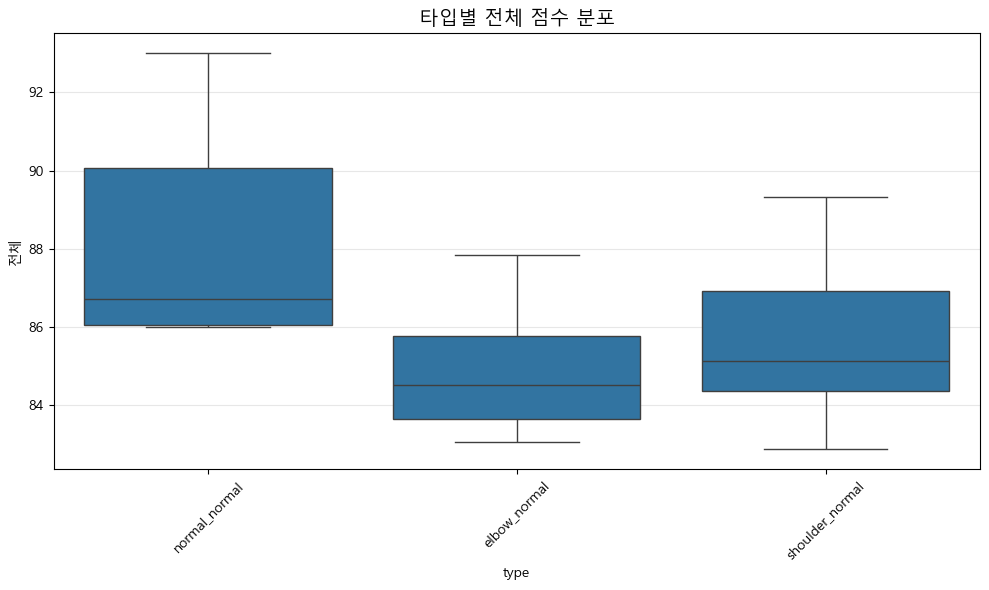

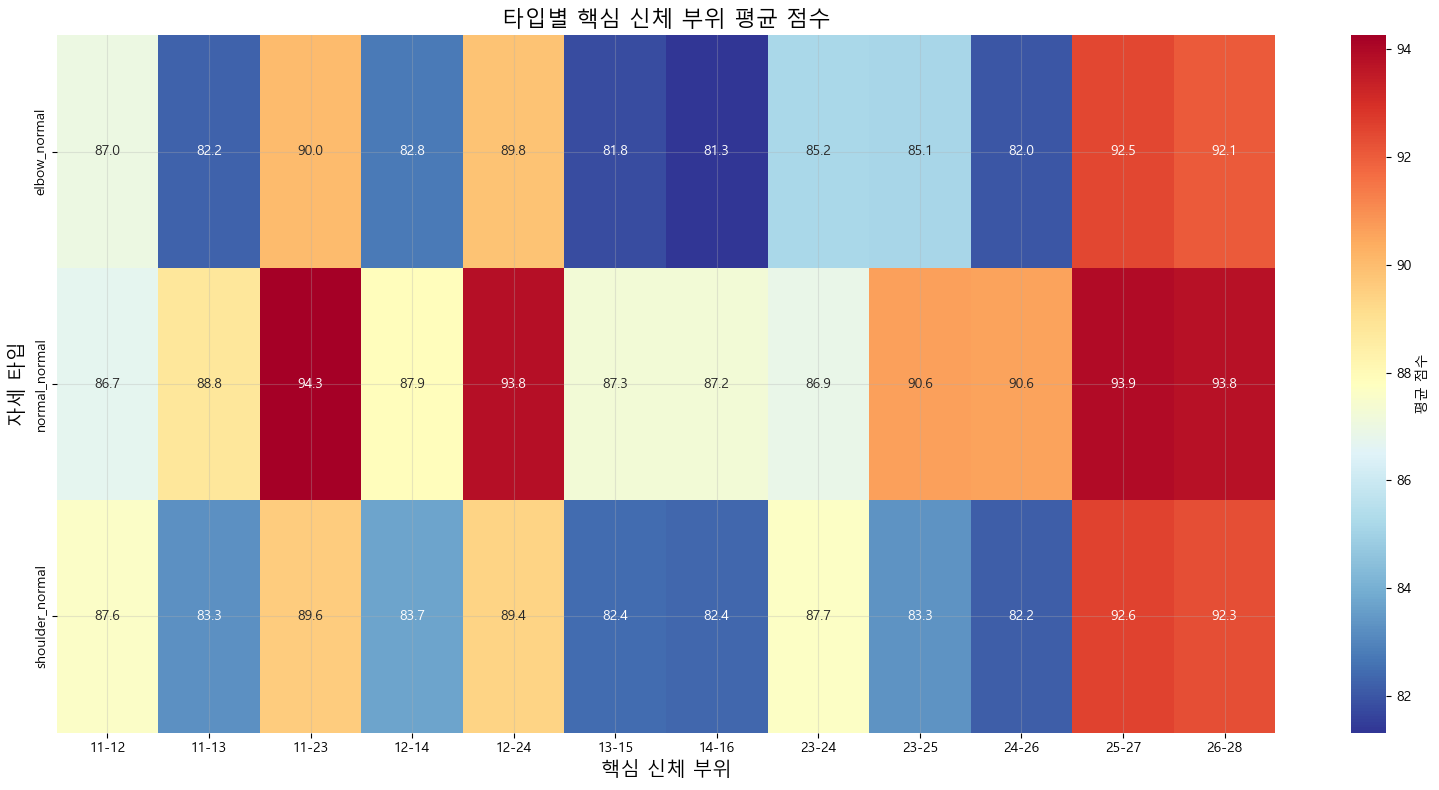

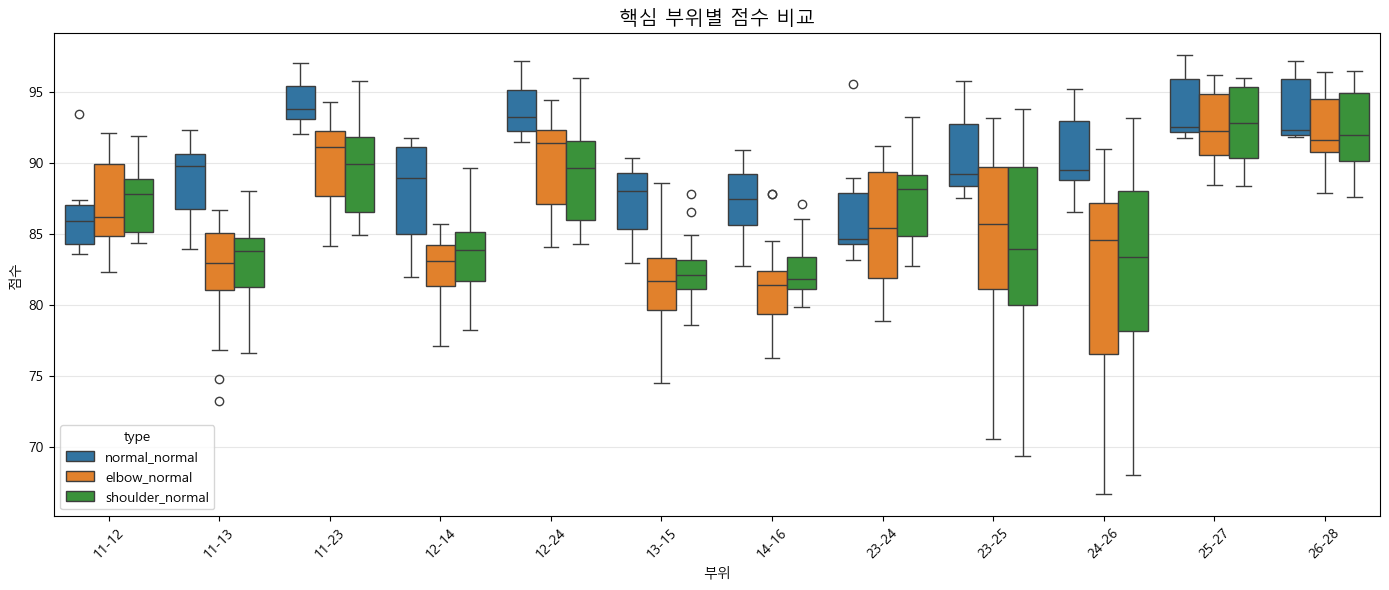

In [9]:
def create_visualizations(result_df, part_means, key_parts):
    """시각화 생성"""
    
    # 1. 전체 점수 분포 비교
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=result_df, x='type', y='전체')
    plt.title('타입별 전체 점수 분포', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 2. 핵심 신체 부위별 평균 점수 히트맵
    plt.figure(figsize=(16, 8))
    sns.heatmap(part_means, annot=True, fmt='.1f', cmap='RdYlBu_r', 
                cbar_kws={'label': '평균 점수'})
    plt.title('타입별 핵심 신체 부위 평균 점수', fontsize=16)
    plt.xlabel('핵심 신체 부위', fontsize=14)
    plt.ylabel('자세 타입', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # 3. 핵심 부위별 점수 비교
    plt.figure(figsize=(14, 6))
    key_data = result_df[['type'] + key_parts].melt(id_vars=['type'], var_name='부위', value_name='점수')
    sns.boxplot(data=key_data, x='부위', y='점수', hue='type')
    plt.title('핵심 부위별 점수 비교', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

key_parts = ['11-12', '11-13', '11-23', '12-14', '12-24', '13-15', '14-16', 
                '23-24', '23-25', '24-26', '25-27', '26-28']

available_key_parts = [part for part in key_parts if part in result_df.columns]
part_means = result_df.groupby('type')[available_key_parts].mean()

# 시각화 실행
create_visualizations(result_df, part_means, available_key_parts)

# 1. 전체 동작에 대한 검증

In [10]:
result_df.groupby('type')['전체'].agg(['count', 'mean', 'std', 'min', 'max'])

,count,mean,std,min,max
type,,,,,
elbow_normal,28,84.948929,1.535654,83.07,87.85
normal_normal,6,88.245000,3.016712,85.99,93.00
shoulder_normal,24,85.740417,1.840601,82.88,89.33


In [11]:
scores_by_type = [group['전체'].dropna().values for name, group in result_df.groupby('type')]

h_statistic, p_value = stats.kruskal(*scores_by_type)

print("Kruskal-Wallis 검정 결과:")
print(f"H-통계량: {h_statistic:.4f}, p-값: {p_value:.4f}")

if p_value < 0.05:
    print("결론: 타입별 '전체' 점수의 차이는 통계적으로 유의미합니다.")
else:
    print("결론: 타입별 '전체' 점수의 차이는 통계적으로 유의미하지 않습니다.")

Kruskal-Wallis 검정 결과:
H-통계량: 9.5023, p-값: 0.0086
결론: 타입별 '전체' 점수의 차이는 통계적으로 유의미합니다.


# 2. 신체 부위에 대한 검증

In [12]:
df = pd.DataFrame()
for part in key_parts:
    tmp = result_df.groupby(['type'])[part].agg(['mean', 'std', 'min', 'max'])
    tmp['part'] = part
    df = pd.concat([df, tmp], axis = 0)
df

,mean,std,min,max,part
type,,,,,
elbow_normal,86.986071,3.074658,82.35,92.13,11-12
normal_normal,86.685000,3.615991,83.58,93.44,11-12
shoulder_normal,87.607917,2.318793,84.37,91.91,11-12
elbow_normal,82.240357,3.454761,73.29,86.72,11-13
normal_normal,88.773333,3.187122,83.94,92.33,11-13
shoulder_normal,83.287500,2.903845,76.61,88.04,11-13
elbow_normal,90.049643,3.001873,84.17,94.28,11-23
normal_normal,94.251667,1.874870,92.04,97.06,11-23
shoulder_normal,89.567083,3.514140,84.93,95.79,11-23


In [13]:
for part in key_parts:
    scores_by_type = [group[part].dropna().values for name, group in result_df.groupby('type')]
    # Kruskal-Wallis 검정 수행
    h_statistic, p_value = stats.kruskal(*scores_by_type)
    
    print(f"\n신체부위 {part}에 대한 Kruskal-Wallis 검정 결과:")
    print(f"H-통계량: {h_statistic:.4f}, p-값: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"결론: 신체부위 '{part}'의 점수 차이는 통계적으로 유의미합니다.")
    else:
        print(f"결론: 신체부위 '{part}'의 점수 차이는 통계적으로 유의미하지 않습니다.")



신체부위 11-12에 대한 Kruskal-Wallis 검정 결과:
H-통계량: 1.1574, p-값: 0.5606
결론: 신체부위 '11-12'의 점수 차이는 통계적으로 유의미하지 않습니다.

신체부위 11-13에 대한 Kruskal-Wallis 검정 결과:
H-통계량: 11.2717, p-값: 0.0036
결론: 신체부위 '11-13'의 점수 차이는 통계적으로 유의미합니다.

신체부위 11-23에 대한 Kruskal-Wallis 검정 결과:
H-통계량: 9.7724, p-값: 0.0075
결론: 신체부위 '11-23'의 점수 차이는 통계적으로 유의미합니다.

신체부위 12-14에 대한 Kruskal-Wallis 검정 결과:
H-통계량: 7.7848, p-값: 0.0204
결론: 신체부위 '12-14'의 점수 차이는 통계적으로 유의미합니다.

신체부위 12-24에 대한 Kruskal-Wallis 검정 결과:
H-통계량: 8.1193, p-값: 0.0173
결론: 신체부위 '12-24'의 점수 차이는 통계적으로 유의미합니다.

신체부위 13-15에 대한 Kruskal-Wallis 검정 결과:
H-통계량: 11.8842, p-값: 0.0026
결론: 신체부위 '13-15'의 점수 차이는 통계적으로 유의미합니다.

신체부위 14-16에 대한 Kruskal-Wallis 검정 결과:
H-통계량: 13.9362, p-값: 0.0009
결론: 신체부위 '14-16'의 점수 차이는 통계적으로 유의미합니다.

신체부위 23-24에 대한 Kruskal-Wallis 검정 결과:
H-통계량: 3.8049, p-값: 0.1492
결론: 신체부위 '23-24'의 점수 차이는 통계적으로 유의미하지 않습니다.

신체부위 23-25에 대한 Kruskal-Wallis 검정 결과:
H-통계량: 5.2790, p-값: 0.0714
결론: 신체부위 '23-25'의 점수 차이는 통계적으로 유의미하지 않습니다.

신체부위 24-26에 대한 Kruskal-Wallis 검정 결과:
H-통계량: 7.88

# 3. 진단 함수
* 점수 저장
* 기존 점수 비교
* 이건 나중에 agent의 툴로 사용될 것임

In [20]:
standard_df = pd.read_csv('../data/tmp/sdhp_score.csv')
key_parts = ['11-12', '11-13', '11-23', '12-14', '12-24', '13-15', '14-16', 
            '23-24', '23-25', '24-26', '25-27', '26-28', '전체']
standard_dict = {}
for part in key_parts:
    standard_dict[part] = min(standard_df.loc[(standard_df['type'] == 'normal_normal'), part])

standard_dict

{'11-12': 83.58,
 '11-13': 83.94,
 '11-23': 92.04,
 '12-14': 81.97,
 '12-24': 91.46,
 '13-15': 82.98,
 '14-16': 82.75,
 '23-24': 83.17,
 '23-25': 87.52,
 '24-26': 86.59,
 '25-27': 91.78,
 '26-28': 91.83,
 '전체': 85.99}

In [33]:
def rename_point(part):
    points = {
        0: '코',
        1: '왼쪽 눈 (안쪽)',
        2: '왼쪽 눈',
        3: '왼쪽 눈 (바깥쪽)',
        4: '오른쪽 눈 (안쪽)',
        5: '오른쪽 눈',
        6: '오른쪽 눈 (바깥쪽)',
        7: '왼쪽 귀',
        8: '오른쪽 귀',
        9: '입 (왼쪽)',
        10: '입 (오른쪽)',
        11: '왼쪽 어깨',
        12: '오른쪽 어깨',
        13: '왼쪽 팔꿈치',
        14: '오른쪽 팔꿈치',
        15: '왼쪽 손목',
        16: '오른쪽 손목',
        17: '왼쪽 새끼손가락',
        18: '오른쪽 새끼손가락',
        19: '왼쪽 검지',
        20: '오른쪽 검지',
        21: '왼쪽 엄지',
        22: '오른쪽 엄지',
        23: '왼쪽 엉덩이',
        24: '오른쪽 엉덩이',
        25: '왼쪽 무릎',
        26: '오른쪽 무릎',
        27: '왼쪽 발목',
        28: '오른쪽 발목',
        29: '왼쪽 발뒤꿈치',
        30: '오른쪽 발뒤꿈치',
        31: '왼쪽 발끝',
        32: '오른쪽 발끝'
    }
    indices = part.split('-')
    if part == '전체':
        return '전체'
    return f"{points.get(int(indices[0]), '알 수 없는 부위')}-{points.get(int(indices[1]), '알 수 없는 부위')}"

In [34]:
def diagnose_sdhp(new_pose, old_pose, visual_json):
    result_sum, result, score = poseScoring(new_pose, old_pose, visual_json)

    standard_dict = {'11-12': 83.58,
                     '11-13': 83.94,
                     '11-23': 92.04,
                     '12-14': 81.97,
                     '12-24': 91.46,
                     '13-15': 82.98,
                     '14-16': 82.75,
                     '23-24': 83.17,
                     '23-25': 87.52,
                     '24-26': 86.59,
                     '25-27': 91.78,
                     '26-28': 91.83,
                     '전체': 85.99}

    part_list = []
    
    for part in standard_dict.keys():
        part_score = score.loc[score['부위'] == part, '평균점수'].values[0]
        min_score = standard_dict[part]

        if part_score < min_score:
            part_list.append(rename_point(part))

    return result_sum, result, score, part_list

In [37]:
result_sum, result, score, part_list = diagnose_sdhp(elbow_list[index_1][0], normal_list[index_2][0], visual_json)

In [38]:
result_sum

array([[  31.08526062,   39.99834057,   47.90318318, ..., 1827.38438073,
        1839.13473279, 1848.39928074],
       [  67.49071412,   37.53691444,   44.65407668, ..., 1404.67010828,
        1418.09501506, 1424.83026125],
       [ 104.25357026,   44.66853351,   46.94691656, ..., 1344.2001781 ,
        1358.17059125, 1365.23052935],
       ...,
       [3981.72139251, 1738.46489509, 1674.39787759, ..., 1068.85481371,
        1081.33201604, 1086.48860025],
       [4018.10503748, 1747.03992427, 1682.77060289, ..., 1069.71736465,
        1082.42326265, 1087.02485817],
       [4054.37328005, 1755.62586917, 1690.93523866, ..., 1070.80733682,
        1083.80495908, 1088.46866433]])

In [41]:
result.keys()

dict_keys(['shortestPath', 'shortestScoring', '0-1', '0-4', '1-2', '2-3', '3-7', '4-5', '5-6', '6-8', '9-10', '11-12', '11-13', '11-23', '12-14', '12-24', '13-15', '14-16', '15-17', '15-19', '15-21', '16-18', '16-20', '16-22', '17-19', '18-20', '23-24', '23-25', '24-26', '25-27', '26-28', '27-29', '27-31', '28-30', '28-32', '29-31', '30-32'])

In [42]:
score

,부위,평균점수
0,0-1,71.99
1,0-4,70.80
2,1-2,83.50
3,2-3,81.04
4,3-7,82.67
5,4-5,78.62
6,5-6,84.30
7,6-8,83.25
8,9-10,78.93
9,11-12,86.49


In [43]:
part_list

['왼쪽 어깨-왼쪽 팔꿈치',
 '왼쪽 어깨-왼쪽 엉덩이',
 '오른쪽 어깨-오른쪽 엉덩이',
 '왼쪽 팔꿈치-왼쪽 손목',
 '오른쪽 팔꿈치-오른쪽 손목',
 '왼쪽 엉덩이-왼쪽 무릎',
 '오른쪽 엉덩이-오른쪽 무릎',
 '오른쪽 무릎-오른쪽 발목',
 '전체']